In [20]:
import torch
import torch.nn as nn

SEED = 42
STEPS = 2000
LEARNING_RATE = 0.03

torch.manual_seed(SEED)
device = torch.device("cpu")
# device = torch.device("cuda" if torch.cuda.is_available else "cpu")
device # device(type='cuda')

device(type='cpu')

In [21]:
# (function) def tensor(
#     data: Any,
#     dtype: dtype | None = None,
#     device: DeviceLikeType | None = None,
#     requires_grad: bool = False,
#     pin_memory: bool = False
# ) -> Tensor

X_xor = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.1, 1.1]
], dtype=torch.float32, device=device)

# 0과 1의 2개의 class로 분류하는 이진분류
y_xor = torch.tensor([0, 1, 1, 0], dtype=torch.long, device=device)

In [22]:
class ControlledXORMLP(nn.Module):
    def __init__(self, activation_factory):
        super().__init__()
        self.fc1 = nn.Linear(2, 8)
        self.act1 = activation_factory()
        self.fc2 = nn.Linear(8, 8)
        self.act2 = activation_factory()
        self.fc3 = nn.Linear(8, 2)
    def forward(self, x):
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        return self.fc3(x)

# ---------- 동일한 가중치로 세팅된 모델을 2개 준비 ----------
# nn.Identity는 입력을 그대로 통과시키는 층. f(x)=x
linear_model = ControlledXORMLP(nn.Identity).to(device)
relu_model = ControlledXORMLP(nn.ReLU).to(device)

# state_dict -> load (linear_model의 랜덤 값이 공통 출발점)
relu_model.load_state_dict(linear_model.state_dict())

same_start = all(
    torch.equal(p_linear, p_relu)
    for p_linear, p_relu in zip(linear_model.parameters(), relu_model.parameters())
)
assert same_start, "두 모델의 초기 가중치가 같아야 합니다."

In [23]:
def fit_xor(model, steps=STEPS, lr=LEARNING_RATE):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    model.train()
    for _ in range(steps):
        optimizer.zero_grad()
        logits = model(X_xor)
        loss = criterion(logits, y_xor)
        loss.backward()
        optimizer.step()
        history.append(loss.item())

    model.eval()
    with torch.no_grad():
        logits = model(X_xor)
        probs_class1 = torch.softmax(logits, dim=1)[:, 1]
        preds = torch.argmax(logits, dim=1)
        accuracy = (preds == y_xor).float().mean().item()

    return history, probs_class1, preds, accuracy

linear_history, liner_probs, linear_preds, linear_acc = fit_xor(linear_model)
relu_history, relu_probs, relu_preds, relu_acc = fit_xor(relu_model)

print("same initial parameters:", same_start)
print("target                 :", y_xor.tolist())
print("no activation preds    :", linear_preds.tolist())
print("no activation accuracy :", linear_acc)
print("ReLU preds             :", relu_preds.tolist())
print("ReLU accuracy          :", relu_acc)
print("final losses           :", linear_history[-1], relu_history[-1])

same initial parameters: True
target                 : [0, 1, 1, 0]
no activation preds    : [1, 1, 1, 0]
no activation accuracy : 0.75
ReLU preds             : [0, 1, 1, 0]
ReLU accuracy          : 1.0
final losses           : 0.6910867094993591 4.023299879918341e-06


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_43712\634459248.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


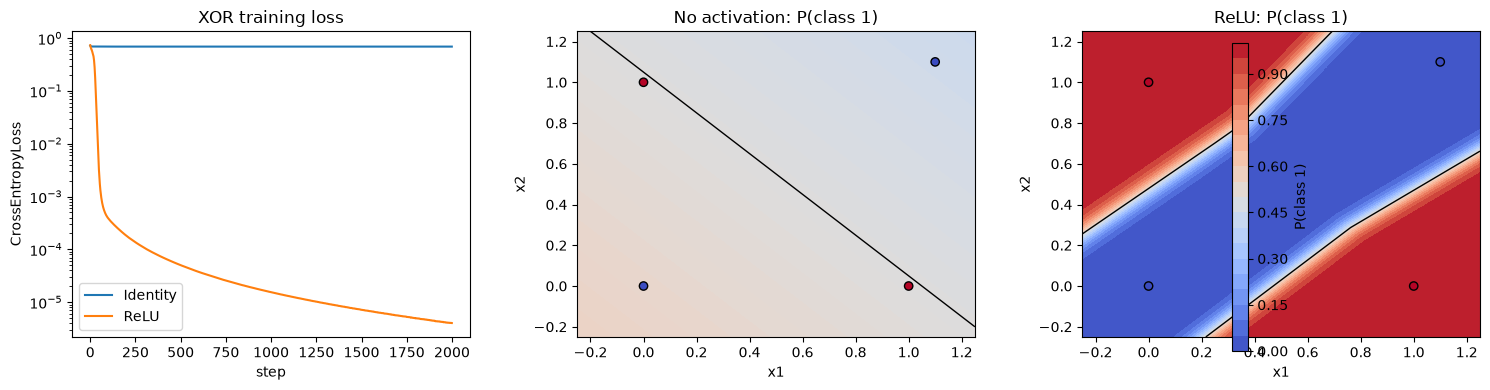

In [24]:
import matplotlib.pyplot as plt

axis = torch.linspace(-0.25, 1.25, 121, device=device)
grid_y, grid_x = torch.meshgrid(axis, axis, indexing="ij")
grid_points = torch.stack([grid_x.reshape(-1), grid_y.reshape(-1)], dim=1)

with torch.no_grad():
    linear_map = torch.softmax(linear_model(grid_points), dim=1)[:, 1]
    relu_map = torch.softmax(relu_model(grid_points), dim=1)[:, 1]

linear_map = linear_map.reshape(len(axis), len(axis))
relu_map = relu_map.reshape(len(axis), len(axis))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(linear_history, label="Identity")
axes[0].plot(relu_history, label="ReLU")
axes[0].set_yscale("log")
axes[0].set_title("XOR training loss")
axes[0].set_xlabel("step")
axes[0].set_ylabel("CrossEntropyLoss")
axes[0].legend()

for ax, prob_map, title in [
    (axes[1], linear_map, "No activation: P(class 1)"),
    (axes[2], relu_map, "ReLU: P(class 1)"),
]:
    contour = ax.contourf(
        grid_x.numpy(),
        grid_y.numpy(),
        prob_map.numpy(),
        levels=20,
        vmin=0.0,
        vmax=1.0,
        cmap="coolwarm",
    )
    ax.contour(
        grid_x.numpy(),
        grid_y.numpy(),
        prob_map.numpy(),
        levels=[0.5],
        colors="black",
        linewidths=1,
    )
    ax.scatter(
        X_xor[:, 0].numpy(),
        X_xor[:, 1].numpy(),
        c=y_xor.numpy(),
        edgecolors="black",
        cmap="coolwarm",
    )
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

fig.colorbar(contour, ax=axes[1:], label="P(class 1)")
plt.tight_layout()
plt.show()

assert linear_preds.shape == y_xor.shape
assert relu_preds.shape == y_xor.shape